## **4. Desarrollo y evaluación de modelos de recomendación**

**Objetivo:** entrenar, evaluar y comparar ocho modelos de recomendación musical basados en contenido para determinar cuál ofrece la mayor cohesión acústica en sus sugerencias.

**Pasos clave:**
1. Imports y carga de datos
2. Preparación del espacio de características
3. Reducción de dimensionalidad (PCA)
4. Funciones de evaluación
5. Modelos sin PCA: similitud del coseno, KNN euclidiana, KNN Manhattan y K-Means sobre las 24 dimensiones originales.
6. Modelos con PCA: los mismos cuatro modelos sobre el espacio reducido.
7. Comparativa final y elección del mejor modelo


> **Recordatorio metodológico:** en ausencia de un *ground truth* de relevancia (historial de escucha o valoraciones explícitas de usuario), la evaluación se apoya en **métricas de cohesión interna**, tal como se justifica en el marco teórico de la memoria. Las métricas empleadas son:
> - **Distancia media intra-vecindario** *(cohesión):* distancia media entre la canción de entrada y sus 5 recomendaciones. Cuanto menor, mayor similitud acústica.
> - **Diversidad intra-lista** *(beyond-accuracy):* distancia media entre las propias 5 recomendaciones entre sí. Cuanto mayor, más variadas son las sugerencias.
>
> Un buen modelo debe equilibrar ambas: alta cohesión (recomendaciones cercanas a la entrada) y diversidad razonable (no recomendar cinco canciones casi idénticas).


### **4.1 Imports y carga de datos**

Importamos las herramientas de `scikit-learn` que utilizaremos a lo largo de todo el análisis y cargaremos el dataset procesado (`dataset_procesado.csv`).

In [1]:
# Librerías estándar
import warnings
warnings.filterwarnings('ignore')
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

# Scikit-learn 
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances, manhattan_distances

# Configuración visual
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
RANDOM_STATE = 42

# Carpeta de salida para figuras 
os.makedirs('figuras/Modelos', exist_ok=True)

#  Carga del dataset procesado
df = pd.read_csv('data/dataset_procesado.csv')
print(f"Dataset cargado: {df.shape[0]:,} canciones | {df.shape[1]} columnas")
df.head(3)

Dataset cargado: 174,582 canciones | 28 columnas


,track_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,...,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,mode_Major,mode_Minor
0,0BRjO6ga9RKCKjfDqeFgWV,Henri Salvador,C'est beau de faire un Show,0,0.613454,0.356223,0.121687,0.910909,0.0,0.339614,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0BjC1NfoEOOusryehmNudP,Martin & les fées,Perdu d'avance (par Gad Elmaleh),1,0.246988,0.571888,0.188355,0.737732,0.0,0.142710,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0CoSDzoNIKCRs124s9uTVy,Joseph Williams,Don't Let Me Be Lonely Tonight,3,0.955823,0.650215,0.246065,0.131113,0.0,0.094241,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### **4.2 Preparación del espacio de características**

Antes de entrenar ningún modelo, es necesario separar el DataFrame en dos estructuras con roles distintos:

- **Metadatos** (`df_metadata`): `track_id`, `artist_name`, `track_name` y `popularity`. Se usan para mostrar resultados al usuario, pero **no participan en el cálculo de distancias**.
- **Matriz de características** (`X`): las 24 dimensiones sobre las que operarán los algoritmos (10 variables numéricas normalizadas + 14 columnas binarias del One-Hot Encoding).

Adicionalmente, se define una **muestra aleatoria de 1.000 canciones** con semilla fija (`RANDOM_STATE = 42`) que actuará como conjunto de evaluación consistente para todos los modelos. Evaluar sobre una muestra representativa en lugar del catálogo completo es la práctica estándar cuando el coste computacional de calcular vecindarios sobre 174.000 instancias hace inviable la comparación directa.


In [2]:
# Separación de metadatos y características
metadata_cols = ['track_id', 'artist_name', 'track_name', 'popularity']
feature_cols = [c for c in df.columns if c not in metadata_cols]

df_metadata = df[metadata_cols].reset_index(drop=True)
X = df[feature_cols].values

print(f"Metadatos: {df_metadata.shape}")
print(f"Matriz de features: {X.shape}")
print(f"\nCaracterísticas del modelo ({len(feature_cols)}):")
print(feature_cols)

Metadatos: (174582, 4)
Matriz de features: (174582, 24)

Características del modelo (24):
['acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'key_A', 'key_A#', 'key_B', 'key_C', 'key_C#', 'key_D', 'key_D#', 'key_E', 'key_F', 'key_F#', 'key_G', 'key_G#', 'mode_Major', 'mode_Minor']


In [3]:
# Muestra de evaluación (1.000 canciones, semilla fija)
N_EVAL = 1000
np.random.seed(RANDOM_STATE)
eval_idx = np.random.choice(len(X), size=N_EVAL, replace=False)
X_eval = X[eval_idx]

print(f"\nMuestra de evaluación: {X_eval.shape[0]:,} canciones seleccionadas aleatoriamente.")


Muestra de evaluación: 1,000 canciones seleccionadas aleatoriamente.


### **4.3 Reducción de dimensionalidad (PCA)**

El Análisis de Componentes Principales (PCA) transforma el espacio original de 24 dimensiones en un subespacio de menor dimensión que retiene la mayor parte de la varianza informativa del catálogo. Su aplicación persigue dos objetivos en este proyecto:

1. **Mitigar la multicolinealidad** detectada en el EDA (especialmente entre `energy` y `loudness`, r = +0.82), evitando que variables redundantes inflen artificialmente su peso en el cálculo de distancias.
2. **Reducir el coste computacional** de los algoritmos de vecindario (KNN), que escalan con el número de dimensiones.

El criterio de retención adoptado es el **90% de la varianza explicada**: se selecciona el número mínimo de componentes principales necesario para capturar al menos ese umbral de información. La gráfica de varianza acumulada permite visualizar cuántos componentes resultan suficientes y justifica la decisión de forma objetiva.

> **Nota:** el PCA se ajusta (`fit`) sobre la **totalidad del catálogo** (`X`), no solo sobre la muestra de evaluación. De este modo, los componentes principales reflejan la estructura global del espacio acústico. La transformación (`transform`) se aplica después tanto a `X` completo como a `X_eval`, garantizando consistencia.

Componentes necesarios para retener el 90% de la varianza: 15
Varianza explicada exacta con 15 componentes: 0.9291


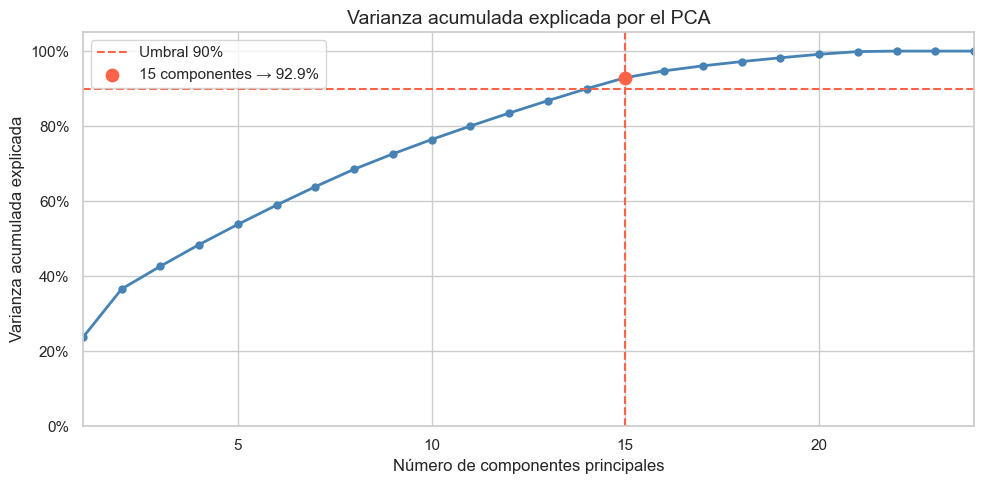

In [ ]:
# Ajuste del PCA sobre el catálogo completo
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)
n_componentes_90 = np.argmax(varianza_acumulada >= 0.90) + 1

print(f"Componentes necesarios para retener el 90% de la varianza: {n_componentes_90}")
print(f"Varianza explicada exacta con {n_componentes_90} componentes: "
      f"{varianza_acumulada[n_componentes_90 - 1]:.4f}")

# Gráfica de varianza acumulada
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada,
        marker='o', markersize=5, color='steelblue', linewidth=2)

ax.axhline(y=0.90, color='tomato', linestyle='--', linewidth=1.5, label='Umbral 90%')
ax.axvline(x=n_componentes_90, color='tomato', linestyle='--', linewidth=1.5)
ax.scatter([n_componentes_90], [varianza_acumulada[n_componentes_90 - 1]],
           color='tomato', zorder=5, s=80,
           label=f'{n_componentes_90} componentes → {varianza_acumulada[n_componentes_90-1]:.1%}')

ax.set_xlabel('Número de componentes principales', fontsize=12)
ax.set_ylabel('Varianza acumulada explicada', fontsize=12)
ax.set_title('Varianza acumulada explicada por el PCA', fontsize=14)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend(fontsize=11)
ax.set_xlim(1, len(varianza_acumulada))
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('figuras/Modelos/pca_varianza_acumulada.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# PCA final con el número de componentes seleccionado
pca = PCA(n_components=n_componentes_90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)             # catálogo completo reducido
X_eval_pca = pca.transform(X[eval_idx])  # muestra de evaluación reducida

print(f"Dimensiones originales: {X.shape}")
print(f"Dimensiones reducidas: {X_pca.shape}")
print(f"Reducción: {X.shape[1]} → {X_pca.shape[1]} dimensiones "
      f"({(1 - X_pca.shape[1]/X.shape[1])*100:.1f}% menos)")

# Exportar el objeto PCA para reutilizarlo en la app
joblib.dump(pca, 'models/modelo_pca.joblib')
print("\nmodelo_pca.joblib exportado correctamente.")

Dimensiones originales: (174582, 24)
Dimensiones reducidas: (174582, 15)
Reducción: 24 → 15 dimensiones (37.5% menos)

modelo_pca.joblib exportado correctamente.


### **4.4 Funciones de evaluación**

Se definen tres funciones reutilizables que se aplicarán de forma idéntica sobre todos los modelos, garantizando que la comparativa sea justa y reproducible.

**`calcular_cohesion(query_vector, recomendaciones, metric)`**
Mide la **distancia media entre la canción de entrada y cada una de sus 5 recomendaciones**. Cuanto menor sea este valor, más acústicamente similares son las sugerencias a la canción original. Es la métrica principal de evaluación.

**`calcular_diversidad(recomendaciones, metric)`**
Mide la **distancia media entre todas las parejas posibles de las 5 recomendaciones entre sí**. Cuanto mayor sea este valor, más variadas son las sugerencias. Es la métrica *beyond-accuracy* complementaria.

**`evaluar_modelo(recomendar_fn, X_eval_sample, metric)`**
Encapsula el bucle completo de evaluación: para cada una de las 1.000 canciones de la muestra, obtiene sus 5 recomendaciones mediante `recomendar_fn`, calcula cohesión y diversidad, y devuelve la media de ambas métricas. Cada modelo definirá su propia `recomendar_fn` y se la pasará como argumento.

Dado que cada modelo usa una métrica de distancia distinta (coseno, euclidiana o Manhattan), y que sus rangos numéricos son incomparables entre sí, los valores brutos no pueden compararse directamente entre modelos de distinta métrica. La normalización y el score ponderado final se calcularán en la sección 4.7, una vez disponibles los resultados de todos los modelos.

In [6]:
from itertools import combinations

def calcular_cohesion(query_vector, recomendaciones, metric='cosine'):
    """
    Distancia media entre la canción de entrada y sus K recomendaciones.
    ----------
    Parámetros:
    query_vector : array (1, n_features) — vector de la canción de entrada.
    recomendaciones: array (K, n_features) — vectores de las K canciones recomendadas.
    metric : 'cosine' | 'euclidean' | 'manhattan'
    --------
    Devuelve:
    float — distancia media intra-vecindario.
    """
    if metric == 'cosine':
        distancias = cosine_distances(query_vector, recomendaciones)[0]
    elif metric == 'euclidean':
        distancias = euclidean_distances(query_vector, recomendaciones)[0]
    else:  # manhattan
        distancias = manhattan_distances(query_vector, recomendaciones)[0]
    return float(np.mean(distancias))

In [7]:
def calcular_diversidad(recomendaciones, metric='cosine'):
    """
    Distancia media entre todas las parejas posibles de las K recomendaciones.
    ----------
    Parámetros:
    recomendaciones: array (K, n_features) — vectores de las K canciones recomendadas.
    metric : 'cosine' | 'euclidean' | 'manhattan'
    --------
    Devuelve:
    float — diversidad intra-lista.
    """
    indices = list(combinations(range(len(recomendaciones)), 2))
    if not indices:
        return 0.0
    pares_a = recomendaciones[[i for i, _ in indices]]
    pares_b = recomendaciones[[j for _, j in indices]]
    if metric == 'cosine':
        distancias = [cosine_distances(pares_a[[k]], pares_b[[k]])[0][0]
                      for k in range(len(indices))]
    elif metric == 'euclidean':
        distancias = [euclidean_distances(pares_a[[k]], pares_b[[k]])[0][0]
                      for k in range(len(indices))]
    else:  # manhattan
        distancias = [manhattan_distances(pares_a[[k]], pares_b[[k]])[0][0]
                      for k in range(len(indices))]
    return float(np.mean(distancias))

In [ ]:
def evaluar_modelo(recomendar_fn, X_eval_sample, metric='cosine'):
    """
    Evalúa un modelo sobre la muestra de evaluación completa.
    Para cada canción de X_eval_sample, obtiene sus 5 recomendaciones
    mediante recomendar_fn y calcula cohesión y diversidad del vecindario.
    Devuelve la media de ambas métricas sobre las N_EVAL canciones.
    ----------
    Parámetros:
    recomendar_fn : callable — recibe array (1, n_features),
                    devuelve array (K, n_features) con las recomendaciones.
    X_eval_sample : array (N_EVAL, n_features) — muestra de canciones de entrada.
    metric : 'cosine' | 'euclidean' | 'manhattan'
    --------
    Devuelve:
    (float, float) — (cohesión_media, diversidad_media)
    """
    cohesiones   = []
    diversidades = []

    for i in range(len(X_eval_sample)):
        query = X_eval_sample[i].reshape(1, -1)
        recomendadas = recomendar_fn(query)  # (K, n_features)
        cohesiones.append(calcular_cohesion(query, recomendadas, metric))
        diversidades.append(calcular_diversidad(recomendadas, metric))

    return float(np.mean(cohesiones)), float(np.mean(diversidades))


print("Funciones de evaluación definidas correctamente:")
print("  · calcular_cohesion → distancia media canción → recomendaciones")
print("  · calcular_diversidad → distancia media entre recomendaciones entre sí")
print("  · evaluar_modelo → bucle completo sobre la muestra de 1.000 canciones")

Funciones de evaluación definidas correctamente:
  · calcular_cohesion → distancia media canción → recomendaciones
  · calcular_diversidad → distancia media entre recomendaciones entre sí
  · evaluar_modelo → bucle completo sobre la muestra de 1.000 canciones


### **4.5 Grupo A — Modelos sin reducción de dimensionalidad**

En este grupo se entrenan y evalúan cuatro modelos operando directamente sobre el espacio vectorial original de **24 dimensiones**. El objetivo es establecer una línea base de rendimiento antes de aplicar PCA, permitiendo cuantificar posteriormente el impacto real de la reducción de dimensionalidad.

Los modelos a comparar son:

|   | Modelo | Métrica de distancia |
|---|--------|----------------------|
| A1 | Similitud del Coseno | Coseno |
| A2 | KNN Euclidiana | Euclidiana |
| A3 | KNN Manhattan | Manhattan |
| A4 | K-Means | Euclidiana |

Cada modelo seguirá el mismo esquema: definición e implementación, entrenamiento y llamada a `evaluar_modelo`. Los resultados parciales se acumularán en el diccionario `resultados` para su uso en la comparativa final de la sección 4.7.

In [9]:
# Diccionario donde se acumularán los resultados de todos los modelos
# Formato: {'nombre_modelo': (cohesion_media, diversidad_media)}
resultados = {}